# Blue Marker Detection Tuning

## How it works
- Blue markers are detected using HSV (Hue-Saturation-Value) color space
- **Hue**: The actual color (blue is typically 100-130 in OpenCV's 0-179 range)
- **Saturation**: Color intensity (low = washed out, high = vivid)
- **Value**: Brightness (low = dark, high = bright)

In [2]:
# Install dependencies if needed
# !pip install opencv-python numpy matplotlib ipywidgets

In [3]:
import sys
sys.path.insert(0, '..')

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from pathlib import Path

from src.config import BlueDetectionConfig
from src.tracker import BlueMarkerDetector, FrameMarkers

%matplotlib inline
plt.rcParams['figure.figsize'] = [14, 8]

## 1. Load Test Image or Video Frame

In [5]:
# OPTION 1: Load from image file
# image_path = "../data/sample_frames/test_image.png"
# frame = cv2.imread(image_path)

# OPTION 2: Extract frame from video
video_path = "../data/jump-threequarters.mp4"  # <-- UPDATE THIS PATH
frame_number = 80  # First frame

cap = cv2.VideoCapture(video_path)
if cap.isOpened():
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ret, frame = cap.read()
    cap.release()
    if ret:
        print(f"Loaded frame {frame_number} from video")
        print(f"Frame shape: {frame.shape}")
    else:
        print("Failed to read frame")
        frame = None
else:
    print(f"Could not open video: {video_path}")
    print("Creating a test image with blue circles instead...")
    
    # Create synthetic test image
    frame = np.ones((720, 480, 3), dtype=np.uint8) * 200  # Gray background
    # Add blue circles at hip, knee, ankle positions
    cv2.circle(frame, (240, 200), 25, (255, 100, 0), -1)  # Hip (blue in BGR)
    cv2.circle(frame, (240, 400), 25, (255, 100, 0), -1)  # Knee
    cv2.circle(frame, (240, 550), 25, (255, 100, 0), -1)  # Ankle

Loaded frame 80 from video
Frame shape: (2160, 1216, 3)


In [6]:
# aspect_ratio = 1920 / 1080
aspect_ratio = frame.shape[1] / frame.shape[0] 
print(f"{aspect_ratio} : {frame.shape[1]} :  {frame.shape[1]}")

0.562962962962963 : 1216 :  1216


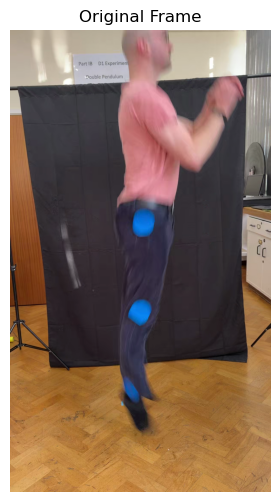

In [7]:
# Display the original frame
if frame is not None:
    # Calculate figure size to maintain aspect ratio (16:9 for 1920x1080)
    aspect_ratio = frame.shape[1] / frame.shape[0]  # width / height
    # aspect_ratio = 30 / 9  # width / height
    fig_height = 6
    fig_width = fig_height * aspect_ratio
    
    plt.figure(figsize=(fig_width, fig_height))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title("Original Frame")
    plt.axis('off')
    plt.show()

## 2. Examine HSV Color Space

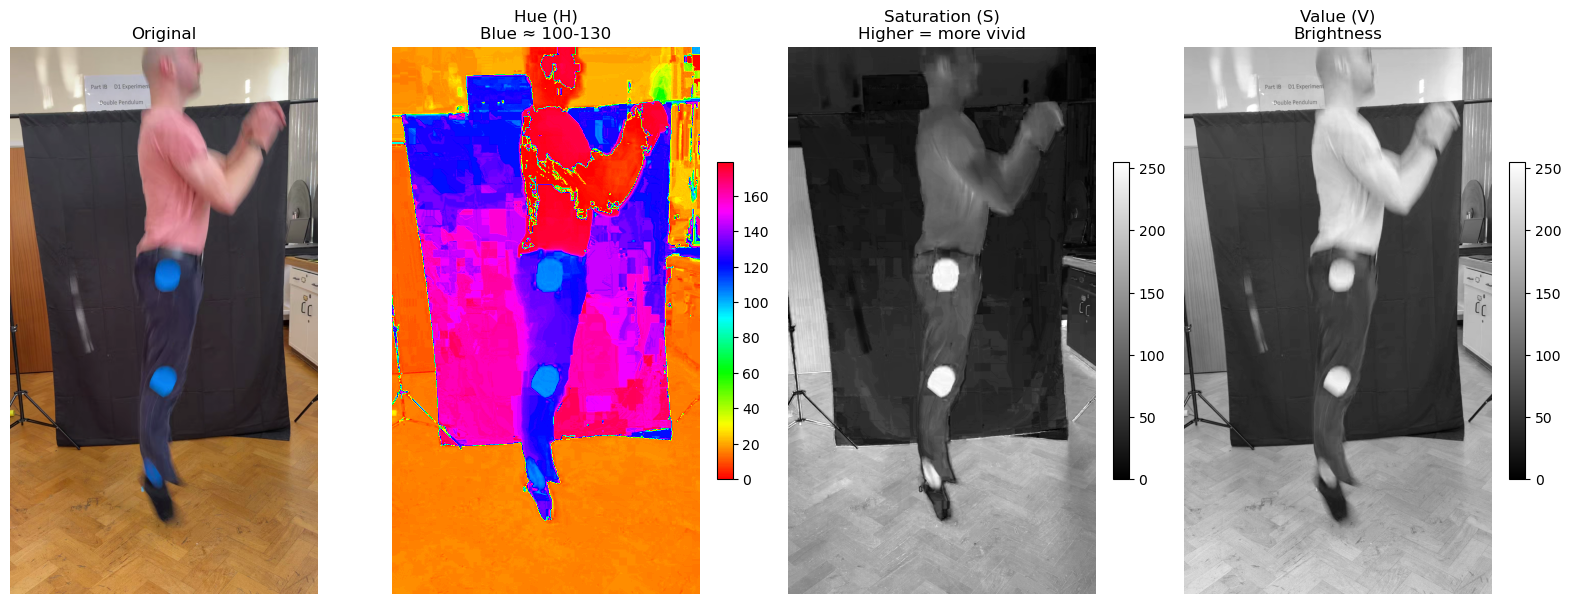

In [9]:
if frame is not None:
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 6))
    
    # Original
    axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    # Hue channel
    im1 = axes[1].imshow(hsv[:,:,0], cmap='hsv', vmin=0, vmax=179)
    axes[1].set_title('Hue (H)\nBlue ≈ 100-130')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Saturation channel
    im2 = axes[2].imshow(hsv[:,:,1], cmap='gray', vmin=0, vmax=255)
    axes[2].set_title('Saturation (S)\nHigher = more vivid')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    # Value channel
    im3 = axes[3].imshow(hsv[:,:,2], cmap='gray', vmin=0, vmax=255)
    axes[3].set_title('Value (V)\nBrightness')
    axes[3].axis('off')
    plt.colorbar(im3, ax=axes[3], fraction=0.046)
    
    plt.tight_layout()
    plt.show()

## 3. Interactive HSV Tuning

In [11]:
# Try to use interactive widgets if available
try:
    from ipywidgets import interact, IntSlider, FloatSlider, Checkbox
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("ipywidgets not installed. Using manual parameter adjustment.")
    print("Install with: pip install ipywidgets")

In [12]:
def test_detection(h_low=90, h_high=130, 
                   s_low=200, s_high=255,
                   v_low=50, v_high=255,
                   min_area=100, max_area=10000,
                   min_circularity=0.5,
                   show_mask=True):
    """
    Test detection with given parameters.
    """
    if frame is None:
        print("No frame loaded!")
        return
    
    # Create config with current parameters
    config = BlueDetectionConfig(
        h_low=h_low, h_high=h_high,
        s_low=s_low, s_high=s_high,
        v_low=v_low, v_high=v_high,
        min_contour_area=min_area,
        max_contour_area=max_area,
        min_circularity=min_circularity
    )
    
    detector = BlueMarkerDetector(config)
    
    # Get detection results
    frame_markers = detector.process_frame(frame)
    mask = detector.create_blue_mask(frame)
    
    # Create visualization
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    
    # Original with detections
    annotated = detector.visualize_detection(frame, frame_markers, show_mask=show_mask)
    axes[0].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Detection Result')
    axes[0].axis('off')
    
    # Mask
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Blue Mask')
    axes[1].axis('off')
    
    # HSV ranges visualization
    axes[2].barh(['Hue', 'Saturation', 'Value'], 
                 [h_high-h_low, s_high-s_low, v_high-v_low],
                 left=[h_low, s_low, v_low],
                 color=['blue', 'green', 'orange'])
    axes[2].set_xlim(0, 255)
    axes[2].axvline(x=179, color='red', linestyle='--', alpha=0.5, label='Hue max=179')
    axes[2].set_title('HSV Ranges')
    axes[2].set_xlabel('Value')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print detection summary
    print(f"\n{'='*50}")
    print(f"DETECTION SUMMARY")
    print(f"{'='*50}")
    print(f"Total markers detected: {len(frame_markers.all_markers)}")
    print(f"Complete detection (all 3): {frame_markers.is_complete}")
    print()
    
    for name, marker in [('Hip', frame_markers.hip), 
                         ('Knee', frame_markers.knee), 
                         ('Ankle', frame_markers.ankle)]:
        if marker:
            print(f"{name:6s}: x={marker.x:.1f}, y={marker.y:.1f}, "
                  f"radius={marker.radius:.1f}, circularity={marker.circularity:.2f}")
        else:
            print(f"{name:6s}: NOT DETECTED")
    
    return config

In [13]:
if HAS_WIDGETS and frame is not None:
    # Interactive version with sliders
    interact(
        test_detection,
        h_low=IntSlider(value=90, min=0, max=179, step=1, description='H Low'),
        h_high=IntSlider(value=120, min=0, max=179, step=1, description='H High'),
        s_low=IntSlider(value=200, min=0, max=255, step=5, description='S Low'),
        s_high=IntSlider(value=255, min=0, max=255, step=5, description='S High'),
        v_low=IntSlider(value=50, min=0, max=255, step=5, description='V Low'),
        v_high=IntSlider(value=255, min=0, max=255, step=5, description='V High'),
        min_area=IntSlider(value=500, min=10, max=5000, step=50, description='Min Area'),
        max_area=IntSlider(value=30000, min=1000, max=50000, step=500, description='Max Area'),
        min_circularity=FloatSlider(value=0.3, min=0.1, max=1.0, step=0.05, description='Circularity'),
        show_mask=Checkbox(value=True, description='Show Mask Overlay')
    )
else:
    # Manual version - adjust parameters here
    print("Running with default parameters. Modify values below and re-run:")
    test_detection(
        h_low=90, h_high=190,      # Hue range for blue
        s_low=200, s_high=255,     # Saturation range
        v_low=50, v_high=255,      # Value (brightness) range
        min_area=100,              # Minimum marker area in pixels
        max_area=10000,            # Maximum marker area
        min_circularity=0.5,       # How circular (1.0 = perfect circle)
        show_mask=True
    )

interactive(children=(IntSlider(value=90, description='H Low', max=179), IntSlider(value=120, description='H H…

## 4. Sample Blue Colors from Image

In [15]:
def sample_color_at_point(x, y, radius=5):
    """
    Sample the average HSV color at a point (with small radius for averaging).
    """
    if frame is None:
        return None
    
    h, w = frame.shape[:2]
    x, y = int(x), int(y)
    
    # Ensure we're within bounds
    x1 = max(0, x - radius)
    x2 = min(w, x + radius)
    y1 = max(0, y - radius)
    y2 = min(h, y + radius)
    
    # Extract region and convert to HSV
    region = frame[y1:y2, x1:x2]
    hsv_region = cv2.cvtColor(region, cv2.COLOR_BGR2HSV)
    
    # Calculate mean HSV
    mean_hsv = hsv_region.mean(axis=(0, 1))
    
    return {
        'h': mean_hsv[0],
        's': mean_hsv[1],
        'v': mean_hsv[2]
    }

# Sample some points - UPDATE THESE COORDINATES to match your markers!
# You can get approximate coordinates by looking at the detection output above
sample_points = [
    (240, 200),  # Approximate hip position
    (240, 400),  # Approximate knee position  
    (240, 550),  # Approximate ankle position
]

print("HSV values at sample points:")
print("(Update sample_points list with actual marker coordinates)\n")

for i, (x, y) in enumerate(sample_points):
    hsv = sample_color_at_point(x, y)
    if hsv:
        print(f"Point {i+1} ({x}, {y}): H={hsv['h']:.1f}, S={hsv['s']:.1f}, V={hsv['v']:.1f}")

HSV values at sample points:
(Update sample_points list with actual marker coordinates)

Point 1 (240, 200): H=18.5, S=33.4, V=205.6
Point 2 (240, 400): H=124.0, S=26.0, V=68.0
Point 3 (240, 550): H=123.9, S=26.6, V=67.2


## 5. Save The Configuration

In [17]:
# Create your final configuration
# UPDATE THESE VALUES based on your tuning above!

final_config = BlueDetectionConfig(
    # HSV bounds for blue detection
    h_low=90,
    h_high=130,
    s_low=200,
    s_high=255,
    v_low=50,
    v_high=255,
    
    # Morphological operations
    morph_kernel_size=5,
    morph_iterations=2,
    
    # Contour filtering
    min_contour_area=500,
    max_contour_area=30000,
    min_circularity=0.3,
    
    # Expected markers
    num_markers=3
)

print("Final configuration:")
print(final_config)

Final configuration:
BlueDetectionConfig(
  HSV Lower: (90, 200, 50)
  HSV Upper: (130, 255, 255)
  Min Area: 500
  Max Area: 30000
  Circularity: 0.3
)


In [18]:
# Save configuration to file
config_path = "../data/detection_config.json"
final_config.save(config_path)
print(f"Configuration saved to: {config_path}")

Configuration saved to: ../data/detection_config.json


In [19]:
# Test loading it back
loaded_config = BlueDetectionConfig.load(config_path)
print("Loaded configuration:")
print(loaded_config)

Loaded configuration:
BlueDetectionConfig(
  HSV Lower: (90, 200, 50)
  HSV Upper: (130, 255, 255)
  Min Area: 500
  Max Area: 30000
  Circularity: 0.3
)


## 6. Test on Multiple Frames

In [21]:
def test_multiple_frames(video_path, frame_indices, config):
    """
    Test detection on multiple frames from a video.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Could not open video: {video_path}")
        return
    
    detector = BlueMarkerDetector(config)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    n_frames = len(frame_indices)
    
    # Read first frame to get dimensions for aspect ratio
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_indices[0])
    ret, sample_frame = cap.read()
    if ret:
        aspect_ratio = sample_frame.shape[1] / sample_frame.shape[0]  # width / height
    else:
        aspect_ratio = 16/9  # Default to 16:9
    
    # Set figure size to maintain aspect ratio
    fig_height = 6
    fig_width_per_frame = fig_height * aspect_ratio
    
    fig, axes = plt.subplots(1, n_frames, figsize=(fig_width_per_frame*n_frames, fig_height))
    if n_frames == 1:
        axes = [axes]
    
    for i, frame_idx in enumerate(frame_indices):
        if frame_idx >= total_frames:
            print(f"Frame {frame_idx} exceeds video length ({total_frames})")
            continue
            
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        
        if ret:
            markers = detector.process_frame(frame, frame_idx)
            annotated = detector.visualize_detection(frame, markers)
            
            axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
            axes[i].set_title(f'Frame {frame_idx}\nDetected: {len(markers.all_markers)}/3')
            axes[i].axis('off')
    
    cap.release()
    plt.tight_layout()
    plt.show()

# Test on several frames throughout the video
# test_multiple_frames(video_path, [0, 30, 60, 90, 120], final_config)

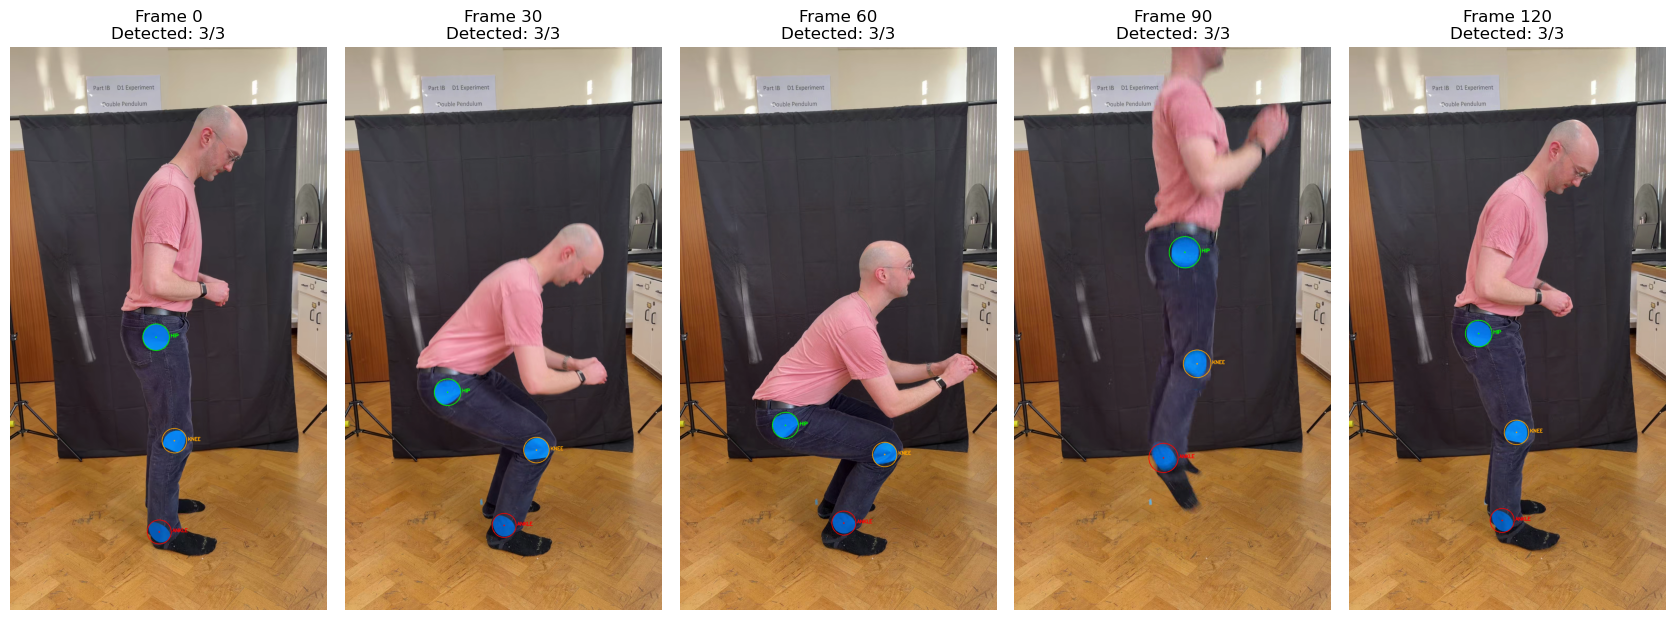

In [22]:
test_multiple_frames(video_path, [0, 30, 60, 90, 120], final_config)

---

## Quick Reference: HSV Tuning Tips

### If markers aren't being detected:
1. **Widen the Hue range** (try h_low=80, h_high=140)
2. **Lower the Saturation minimum** (try s_low=50)
3. **Lower the Value minimum** (try v_low=30)
4. **Decrease min_circularity** (try 0.3)

### If too many things are detected:
1. **Narrow the Hue range** around your markers' actual hue
2. **Raise the Saturation minimum** (try s_low=150)
3. **Increase min_area** to filter small noise
4. **Increase min_circularity** (try 0.7)

### Common blue marker HSV ranges:
- **Bright blue markers**: H=100-120, S=150-255, V=100-255
- **Cyan-ish blue**: H=85-105, S=100-255, V=100-255
- **Dark blue**: H=100-130, S=100-255, V=50-200